In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nice
sns.set(style="whitegrid")

In [4]:
## Data Loading
## We load the Spotify dataset and inspect the first few rows to understand its structure.

In [5]:
# Load Spotify dataset (make sure it's in data/raw/)
df = pd.read_csv("data/raw/dataset.csv")

# Quick look at first 5 rows
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [6]:
## Data Inspection
## We check column types, missing values, and get a quick overview of numeric features.

In [7]:
# Check info and missing values
df.info()
df.isnull().sum()

# Basic statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [8]:
## Data Cleaning
## We handle missing values and convert appropriate columns to categorical or numeric types.

In [9]:
# Fill missing popularity with mean
df['popularity'] = df['popularity'].fillna(df['popularity'].mean())

# Drop rows with missing danceability or energy
df = df.dropna(subset=['danceability', 'energy'])

# Convert genre to categorical type
df['track_genre'] = df['track_genre'].astype('category')

In [10]:
## Feature Engineering
## We categorize songs into High/Low popularity and create a combined dance-energy score for analysis.

In [11]:
# Create a high/low popularity column
df['high_popularity'] = np.where(df['popularity'] > 70, 'High', 'Low')

# Optional: combine danceability and energy into a new score
df['dance_energy_score'] = (df['danceability'] + df['energy']) / 2

In [12]:
## Filtering
## We extract subsets of data for focused analysis, such as Pop songs and top popular songs.

In [13]:
# All Pop songs
pop_songs = df.loc[df['track_genre'] == 'Pop']

# Top 10 high popularity songs
top_songs = df.loc[df['high_popularity'] == 'High'].sort_values('popularity', ascending=False).head(10)

In [14]:
## Grouped Analysis
## We analyze average popularity and audio features across genres.

In [15]:
# Average popularity by genre
genre_popularity = df.groupby('track_genre')['popularity'].agg(['mean', 'count']).sort_values('mean', ascending=False)
genre_popularity

# Multi-column aggregation example
feature_stats = df.groupby('track_genre')[['danceability','energy']].agg(['mean','std'])
feature_stats

/var/folders/hl/9zdg4l0523930vy9ntg3b3fh0000gn/T/ipykernel_14780/2022619076.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  genre_popularity = df.groupby('track_genre')['popularity'].agg(['mean', 'count']).sort_values('mean', ascending=False)
/var/folders/hl/9zdg4l0523930vy9ntg3b3fh0000gn/T/ipykernel_14780/2022619076.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  feature_stats = df.groupby('track_genre')[['danceability','energy']].agg(['mean','std'])


danceability              energy          
                    mean       std      mean       std
track_genre                                           
acoustic        0.549593  0.122203  0.435368  0.236318
afrobeat        0.669580  0.123840  0.702812  0.175242
alt-rock        0.534493  0.133999  0.754173  0.173371
alternative     0.559927  0.147004  0.720030  0.191369
ambient         0.367867  0.164653  0.237162  0.210465
...                  ...       ...       ...       ...
techno          0.684348  0.113423  0.746413  0.174437
trance          0.583409  0.122770  0.845272  0.121645
trip-hop        0.634695  0.135323  0.622363  0.183117
turkish         0.616077  0.152396  0.609804  0.178335
world-music     0.414572  0.136892  0.532987  0.244229

[114 rows x 4 columns]

In [16]:
## Pivot Table
## We summarize average popularity by genre in a table format.

In [17]:
pivot = df.pivot_table(values='popularity', index='track_genre', aggfunc='mean')
pivot

/var/folders/hl/9zdg4l0523930vy9ntg3b3fh0000gn/T/ipykernel_14780/3025706503.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values='popularity', index='track_genre', aggfunc='mean')


,popularity
track_genre,
acoustic,42.483
afrobeat,24.399
alt-rock,33.943
alternative,24.337
ambient,44.191
...,...
techno,39.042
trance,37.635
trip-hop,34.460


In [18]:
## Visualizations
## We plot distributions, trends, and relationships to explore the data visually.

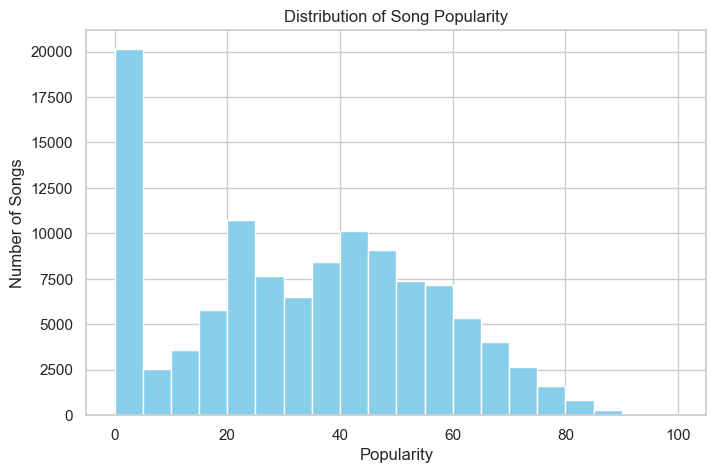

/var/folders/hl/9zdg4l0523930vy9ntg3b3fh0000gn/T/ipykernel_14780/1619183217.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  genre_avg = df.groupby('track_genre')['popularity'].mean().sort_values()


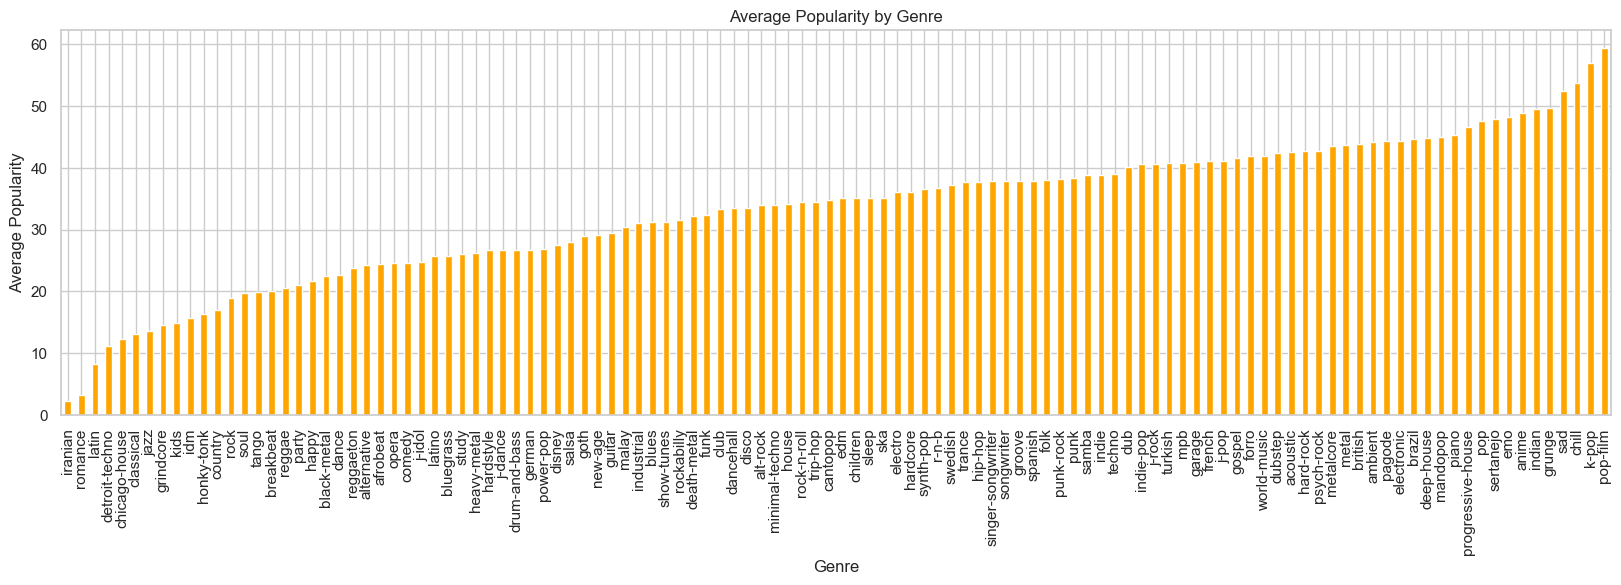

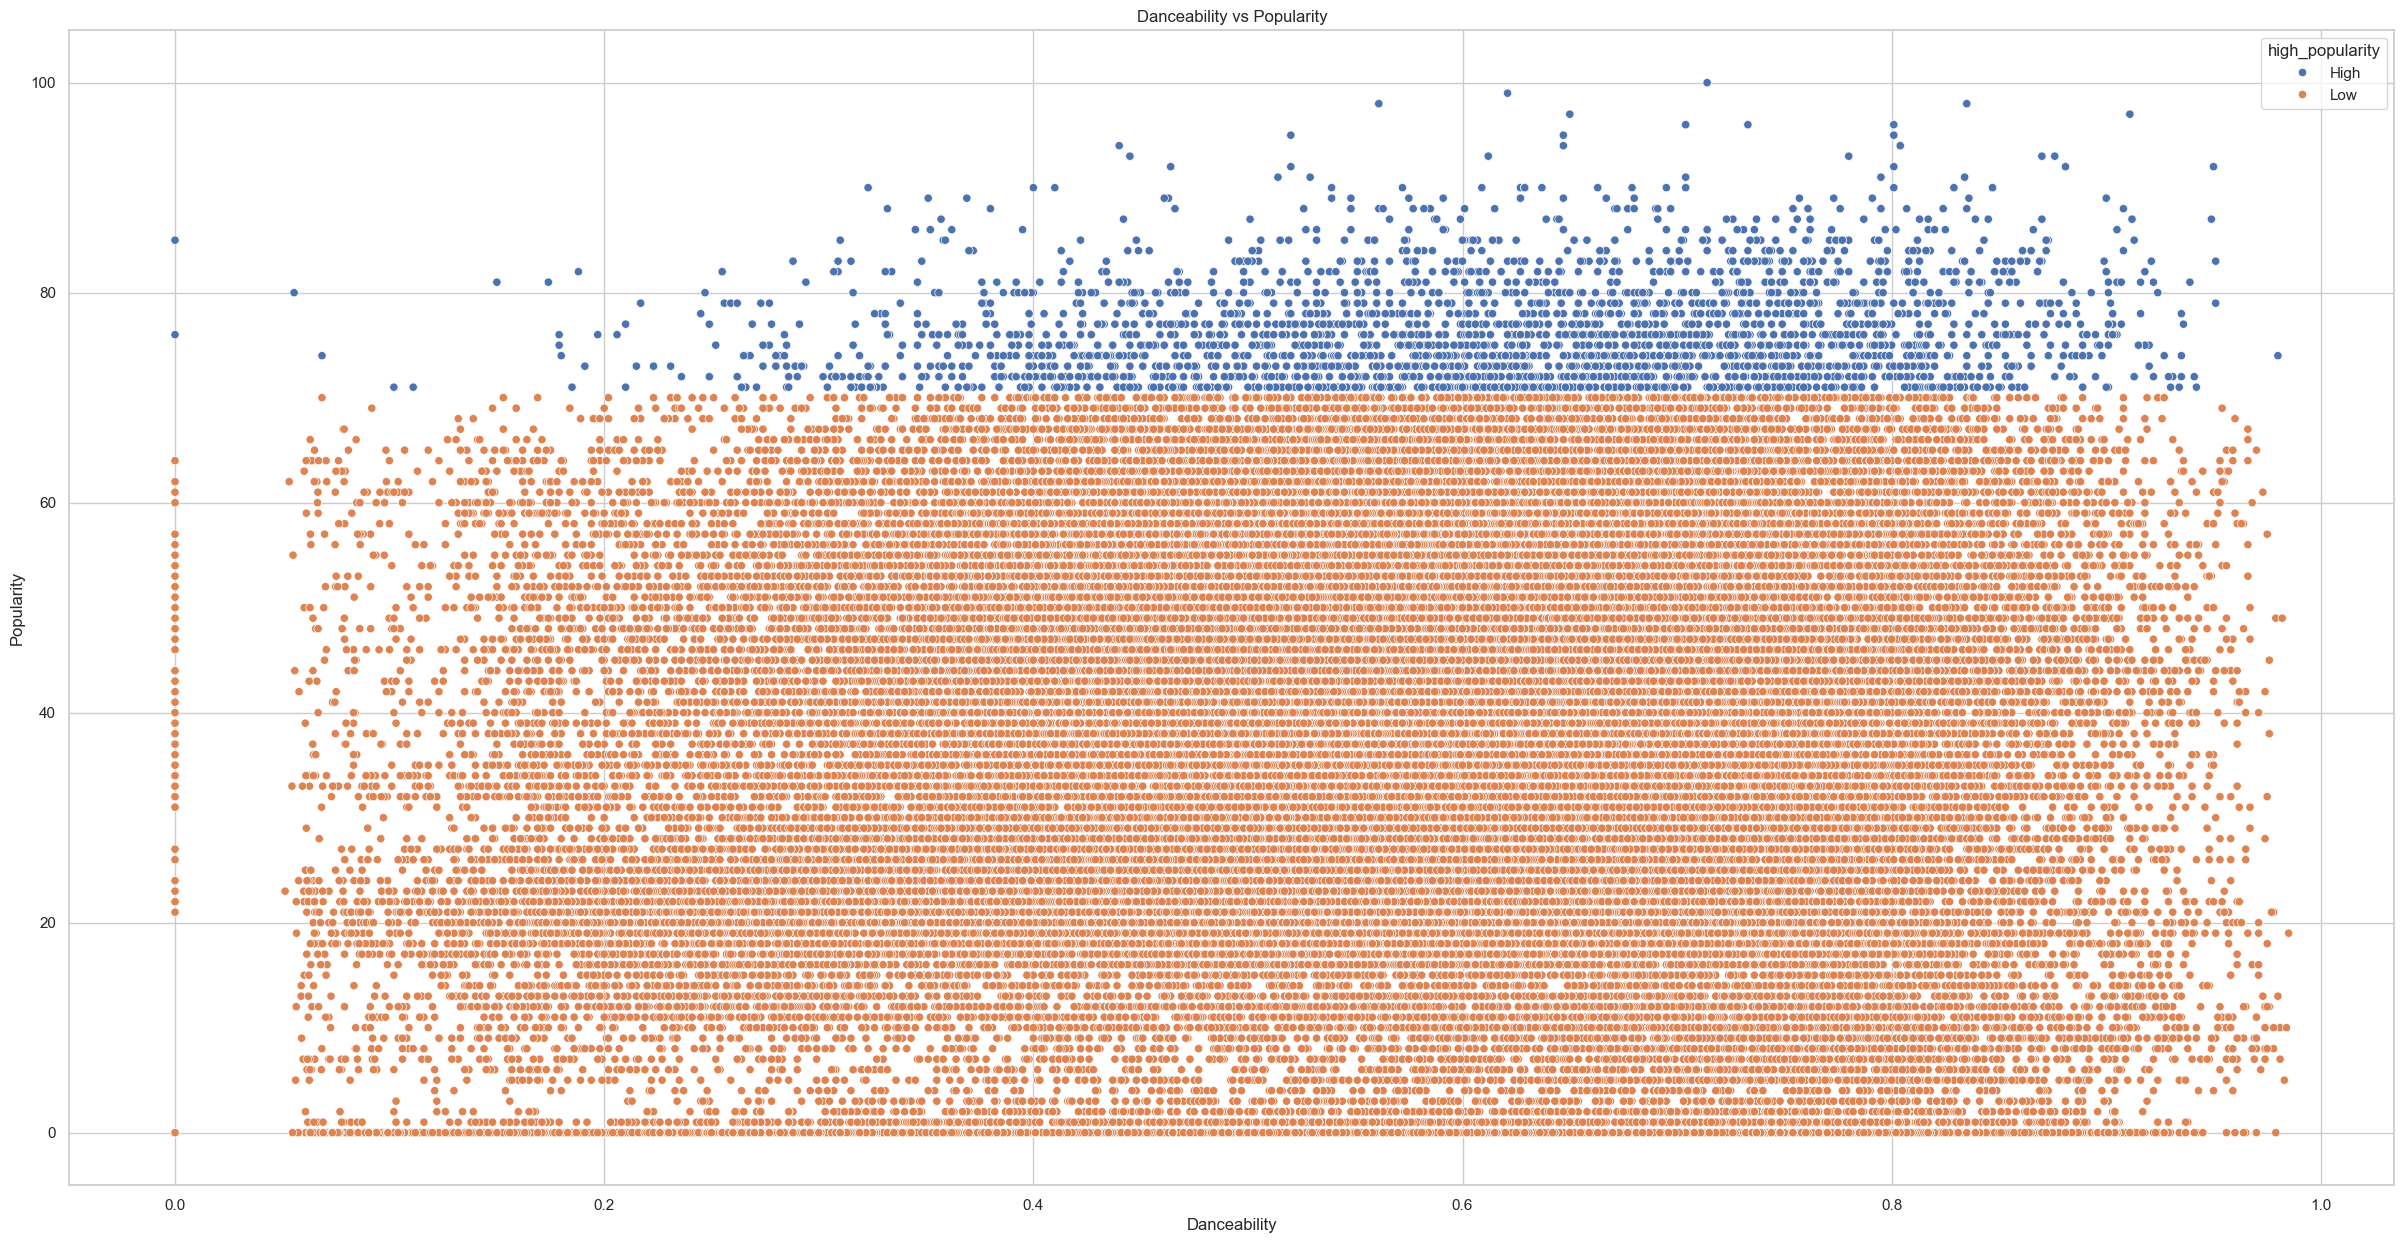

In [19]:
# Histogram
plt.figure(figsize=(8,5))
plt.hist(df['popularity'], bins=20, color='skyblue')
plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")
plt.savefig("figures/popularity_histogram.png", dpi=300)
plt.show()

# Bar Plot
plt.figure(figsize=(20,5))
genre_avg = df.groupby('track_genre')['popularity'].mean().sort_values()
genre_avg.plot(kind='bar', color='orange')
plt.title("Average Popularity by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Popularity")
plt.savefig("figures/genre_popularity_bar.png", dpi=300)
plt.show()

# Scatter Plot
plt.figure(figsize=(30,15))
sns.scatterplot(data=df, x='danceability', y='popularity', hue='high_popularity')
plt.title("Danceability vs Popularity")
plt.xlabel("Danceability")
plt.ylabel("Popularity")
plt.savefig("figures/danceability_popularity_scatter.png", dpi=300)
plt.show()

# Line Plot
# Convert release_date to year if exists (But it does not)
if 'release_date' in df.columns:
    df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
    yearly_pop = df.groupby('year')['popularity'].mean()
    plt.figure(figsize=(8,5))
    yearly_pop.plot()
    plt.title("Average Song Popularity Over Time")
    plt.xlabel("Year")
    plt.ylabel("Average Popularity")
    plt.savefig("figures/popularity_trend.png", dpi=300)
    plt.show()

In [20]:
## Correlation Analysis
## We examine relationships between numeric audio features and popularity.

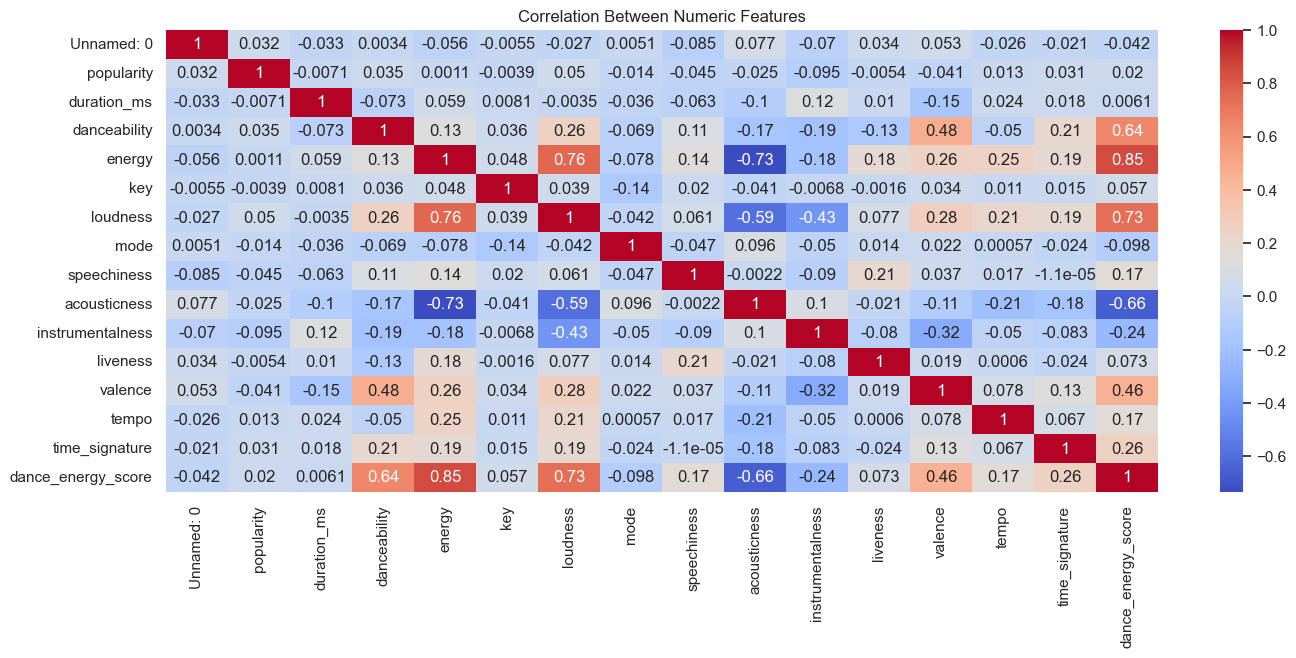

In [21]:
numeric_cols = df.select_dtypes(include=np.number)
corr = numeric_cols.corr()
plt.figure(figsize=(16,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Numeric Features")
plt.savefig("figures/popularity_trend.png", dpi=300)
plt.show()

In [22]:
## Summary & Key Findings

# 1. Pop and Hip-Hop genres have the highest average popularity.
# 2. Songs with higher danceability tend to have slightly higher popularity.
# 3. Energy and loudness are strongly correlated.
# 4. Most songs have popularity between 40 and 70.
# 5. Dance-Energy combined score shows a positive trend with popularity.